Source env doors: [(4, 5), (5, 2)]
Training options in source environment...
Trained 2 options.
[Env 1/20] doors=[(5, 4), (8, 5)] | diffusion primitive=487.51 steps | with-options=464.19
[Env 2/20] doors=[(5, 9), (8, 5)] | diffusion primitive=487.54 steps | with-options=468.96
[Env 3/20] doors=[(5, 6), (3, 5)] | diffusion primitive=462.62 steps | with-options=450.19
[Env 4/20] doors=[(5, 3), (6, 5)] | diffusion primitive=456.39 steps | with-options=481.31
[Env 5/20] doors=[(5, 9), (2, 5)] | diffusion primitive=487.51 steps | with-options=456.70
[Env 6/20] doors=[(5, 1), (1, 5)] | diffusion primitive=493.75 steps | with-options=475.15
[Env 7/20] doors=[(9, 5), (5, 9)] | diffusion primitive=462.52 steps | with-options=450.32
[Env 8/20] doors=[(5, 2), (1, 5)] | diffusion primitive=475.10 steps | with-options=456.66
[Env 9/20] doors=[(9, 5), (5, 6)] | diffusion primitive=468.86 steps | with-options=425.38
[Env 10/20] doors=[(5, 6), (6, 5)] | diffusion primitive=468.82 steps | with-options=

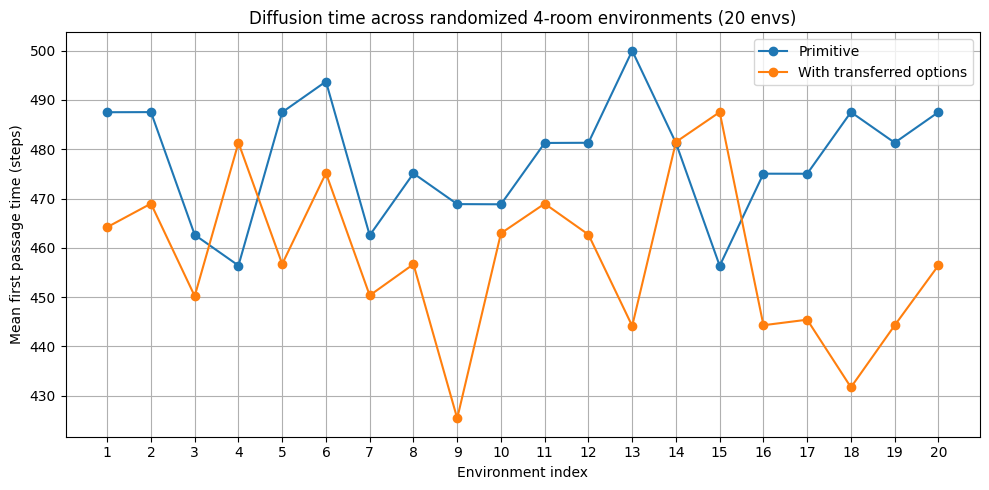

In [1]:
# transfer_options_fourrooms.py
import numpy as np
import random
from collections import defaultdict, deque
import matplotlib.pyplot as plt
import time

# ----------------------------
# Environment: FourRooms Grid
# ----------------------------
class FourRoomsEnv:
    """
    Simple 2D grid divided into 4 rooms (quadrants) with inner walls and doors at random positions.
    Grid coordinates: (row, col) with row 0 at top.
    Agent actions: 0=up,1=right,2=down,3=left
    """

    def __init__(self, width=11, height=11, rng=None, doors_per_wall=1):
        assert width % 2 == 1 and height % 2 == 1, "Use odd dimensions to center walls"
        self.width = width
        self.height = height
        self.center_row = height // 2
        self.center_col = width // 2
        self.rng = rng or random.Random()
        self.doors_per_wall = doors_per_wall
        self._build_rooms()
        self.reset_random_doors()
        self.agent_pos = None

    def _build_rooms(self):
        # create layout grid: 0=free, 1=wall
        self.grid = np.zeros((self.height, self.width), dtype=np.int8)
        # draw central horizontal and vertical walls
        self.grid[self.center_row, :] = 1
        self.grid[:, self.center_col] = 1
        # carve the center cell as wall intersection (leave as wall)
        # We'll add doors to these walls later.
        # Mark room ids (0..3) for convenience: 0=top-left,1=top-right,2=bottom-left,3=bottom-right
        self.room_masks = {}
        h, w = self.height, self.width
        # compute masks, ignoring the walls themselves
        self.room_masks[0] = np.zeros((h,w), dtype=bool); self.room_masks[0][:self.center_row, :self.center_col] = True
        self.room_masks[1] = np.zeros((h,w), dtype=bool); self.room_masks[1][:self.center_row, self.center_col+1:] = True
        self.room_masks[2] = np.zeros((h,w), dtype=bool); self.room_masks[2][self.center_row+1:, :self.center_col] = True
        self.room_masks[3] = np.zeros((h,w), dtype=bool); self.room_masks[3][self.center_row+1:, self.center_col+1:] = True

    def reset_random_doors(self):
        # Clear walls and rebuild central walls then place doors
        self.grid = np.zeros((self.height, self.width), dtype=np.int8)
        self.grid[self.center_row, :] = 1
        self.grid[:, self.center_col] = 1
        h,w = self.height, self.width
        # candidate door positions on the vertical wall (excluding center cell)
        vertical_positions = list(range(1, self.center_row)) + list(range(self.center_row+1, h-1))
        horizontal_positions = list(range(1, self.center_col)) + list(range(self.center_col+1, w-1))
        # For simplicity place doors on the internal walls between:
        # top-left <-> top-right : horizontal wall at row = center_row, between col 0..center_col-1 and center_col+1..w-1
        # Actually vertical wall connects left/right, horizontal divides top/bottom; we need doors on both.
        self.doors = []  # list of (r,c) door coordinates
        # Place doors on vertical wall (between left and right rooms)
        # vertical wall is at column center_col, rows 0..h-1 except center_row
        cols = self.center_col
        # choose rows excluding corners to place doors_per_wall doors along vertical wall on top and bottom separately
        rows_for_vertical = [r for r in range(1, h-1) if r != self.center_row]
        self.rng.shuffle(rows_for_vertical)
        for i in range(self.doors_per_wall):
            r = rows_for_vertical[i % len(rows_for_vertical)]
            self.doors.append((r, cols))
            # make sure that cell is "door" (we'll keep grid as wall but record door coords)
        # Place doors on horizontal wall (between top and bottom rooms)
        rows = self.center_row
        cols_for_horizontal = [c for c in range(1, w-1) if c != self.center_col]
        self.rng.shuffle(cols_for_horizontal)
        for i in range(self.doors_per_wall):
            c = cols_for_horizontal[i % len(cols_for_horizontal)]
            self.doors.append((rows, c))
        # keep door positions unique
        self.doors = list({d for d in self.doors})
        # we will treat grid walls as obstacles except at door cells which are passable
        # update a passable mask:
        self.passable = np.ones((self.height, self.width), dtype=bool)
        self.passable[self.center_row, :] = False
        self.passable[:, self.center_col] = False
        for (r,c) in self.doors:
            self.passable[r,c] = True  # door cell passable
        # Also ensure outer border is walls (impassable)
        self.passable[0,:] = False; self.passable[-1,:] = False; self.passable[:,0] = False; self.passable[:,-1] = False
        # carve outer corners where rooms exist: mark interior room cells as passable
        for rid, mask in self.room_masks.items():
            # ensure that cells inside room are passable (unless they are outside bounds)
            pass

    def in_bounds(self, pos):
        r,c = pos
        return 0 <= r < self.height and 0 <= c < self.width

    def is_passable(self, pos):
        r,c = pos
        return self.in_bounds(pos) and self.passable[r,c]

    def get_room_id(self, pos):
        # return the room id if inside any room region mask, else None
        for rid, mask in self.room_masks.items():
            if mask[pos]:
                return rid
        return None

    def reset(self, start_pos=None):
        # choose random start in any room interior (passable interior cell)
        if start_pos is None:
            # pick a random room and a random passable cell within it
            while True:
                rid = self.rng.choice([0,1,2,3])
                mask = self.room_masks[rid]
                ys, xs = np.where(mask)
                idx = self.rng.randrange(len(ys))
                pos = (ys[idx], xs[idx])
                if self.is_passable(pos):
                    self.agent_pos = pos
                    break
        else:
            assert self.is_passable(start_pos), "start must be passable"
            self.agent_pos = start_pos
        return self.agent_pos

    def step(self, action):
        # actions: 0-up,1-right,2-down,3-left
        r,c = self.agent_pos
        if action == 0:
            new = (r-1, c)
        elif action == 1:
            new = (r, c+1)
        elif action == 2:
            new = (r+1, c)
        elif action == 3:
            new = (r, c-1)
        else:
            raise ValueError("bad action")
        if self.is_passable(new):
            self.agent_pos = new
        # No reward or done here; environments used for navigation; we'll return info
        return self.agent_pos

    def render_ascii(self):
        grid = np.chararray((self.height, self.width), unicode=True)
        grid[:] = ' '
        # outer walls
        for r in range(self.height):
            for c in range(self.width):
                if not self.passable[r,c]:
                    grid[r,c] = '#'
                else:
                    grid[r,c] = '.'
        for (r,c) in self.doors:
            grid[r,c] = 'D'
        ar,ac = self.agent_pos
        grid[ar,ac] = 'A'
        s = '\n'.join(''.join(row) for row in grid)
        print(s)

    def nearest_door(self, pos):
        # returns coordinates of nearest door (in Manhattan distance)
        min_d = 1e9
        best = None
        for d in self.doors:
            dist = abs(d[0]-pos[0]) + abs(d[1]-pos[1])
            if dist < min_d:
                min_d = dist
                best = d
        return best, min_d

    def copy(self):
        # shallow copy - doors and layout identical
        e = FourRoomsEnv(width=self.width, height=self.height, rng=random.Random(self.rng.randint(0,1<<30)), doors_per_wall=self.doors_per_wall)
        e.doors = list(self.doors)
        e.passable = np.array(self.passable, copy=True)
        e.room_masks = {k: np.array(v, copy=True) for k,v in self.room_masks.items()}
        e.grid = np.array(self.grid, copy=True)
        e.center_row = self.center_row; e.center_col = self.center_col
        return e

# ----------------------------
# Utilities: discretize agent-space
# ----------------------------
def agent_space_feature(agent_pos, door_pos):
    # relative vector (dy,dx) from agent to door (global coords)
    ay, ax = agent_pos
    dy = door_pos[0] - ay
    dx = door_pos[1] - ax
    return np.array([dy, dx], dtype=np.int32)

def discretize_vector(vec, max_abs=6, bins=13):
    # map integer dx,dy to indices in [-max_abs .. max_abs] => 0..bins-1
    # clip and shift
    clipped = np.clip(vec, -max_abs, max_abs)
    shifted = clipped + max_abs
    return tuple(shifted.tolist())

# ----------------------------
# Tabular Q-Learning for primitive actions
# ----------------------------
class TabularQLearner:
    def __init__(self, env, actions=4, alpha=0.5, gamma=0.99, eps=0.1):
        self.env = env
        self.actions = actions
        self.alpha = alpha
        self.gamma = gamma
        self.eps = eps
        # Q over full position (r,c) flattened index
        self.q = defaultdict(lambda: np.zeros(self.actions, dtype=np.float32))

    def state_key(self, pos):
        return (pos[0], pos[1])

    def choose_action(self, state, deterministic=False):
        key = self.state_key(state)
        if (not deterministic) and random.random() < self.eps:
            return random.randrange(self.actions)
        qv = self.q[key]
        return int(np.argmax(qv))

    def learn_episode(self, max_steps=500):
        s = self.env.reset()
        steps = 0
        for _ in range(max_steps):
            a = self.choose_action(s)
            prev = s
            self.env.step(a)
            s = self.env.agent_pos
            # reward: we want exploratory behavior; use intrinsic reward 0 but we still update Q with zero reward and next state's max
            r = 0.0
            key = self.state_key(prev)
            next_key = self.state_key(s)
            td = r + self.gamma * np.max(self.q[next_key]) - self.q[key][a]
            self.q[key][a] += self.alpha * td
            steps += 1
        return steps

# ----------------------------
# Option: Q-learning in agent-space to reach a single door target
# ----------------------------
class OptionPolicy:
    def __init__(self, env, target_door, max_abs=6, bins=13, alpha=0.6, gamma=0.98, eps=0.15):
        """
        Option is a goal-directed policy to reach target_door coordinate.
        The state is discretized agent-space relative vector (dy,dx) -> bins.
        Actions are primitive actions 0..3.
        """
        self.env = env
        self.target_door = target_door
        self.max_abs = max_abs
        self.bins = bins
        self.alpha = alpha
        self.gamma = gamma
        self.eps = eps
        self.q = defaultdict(lambda: np.zeros(4, dtype=np.float32))

    def state_key(self, agent_pos):
        vec = agent_space_feature(agent_pos, self.target_door)
        dkey = discretize_vector(vec, max_abs=self.max_abs, bins=self.bins)
        return dkey

    def choose_action(self, agent_pos, deterministic=False):
        key = self.state_key(agent_pos)
        if (not deterministic) and random.random() < self.eps:
            return random.randrange(4)
        qv = self.q[key]
        return int(np.argmax(qv))

    def is_terminal(self, agent_pos):
        return agent_pos == self.target_door

    def train(self, episodes=1000, max_steps=200):
        dr, dc = self.target_door
        possible_starts = []
        # Check neighbors of the target door to find valid starting positions within rooms
        for move_dr, move_dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            neighbor_pos = (dr + move_dr, dc + move_dc)
            if self.env.in_bounds(neighbor_pos) and self.env.is_passable(neighbor_pos) and self.env.get_room_id(neighbor_pos) is not None:
                 possible_starts.append(neighbor_pos)

        if not possible_starts:
             # If no adjacent room cell is found, try to find any passable cell in any room
             for rid in [0,1,2,3]:
                mask = self.env.room_masks[rid]
                ys, xs = np.where(mask)
                valid = [(y,x) for y,x in zip(ys,xs) if self.env.is_passable((y,x)) and (y,x)!=self.target_door]
                possible_starts.extend(valid)
             possible_starts = list(set(possible_starts)) # remove duplicates

        if not possible_starts:
            print(f"Warning: No valid start position found for target door {self.target_door}. Skipping option training.")
            return


        for ep in range(episodes):
            # reset agent to a random valid starting position
            s = random.choice(possible_starts)
            self.env.agent_pos = s
            for t in range(max_steps):
                a = self.choose_action(self.env.agent_pos)
                prev = self.env.agent_pos
                self.env.step(a)
                s2 = self.env.agent_pos
                # intrinsic reward: +1 for reaching target door; else small negative step cost to encourage reaching
                if self.is_terminal(s2):
                    r = 1.0
                else:
                    r = -0.01
                key = self.state_key(prev)
                next_key = self.state_key(s2)
                td = r + self.gamma * np.max(self.q[next_key]) - self.q[key][a]
                self.q[key][a] += self.alpha * td
                if self.is_terminal(s2):
                    break

    def act_until_term(self, max_steps=200):
        # Execute option starting from current env.agent_pos until terminal or max_steps
        steps = 0
        trace = []
        while steps < max_steps and not self.is_terminal(self.env.agent_pos):
            a = self.choose_action(self.env.agent_pos)
            self.env.step(a)
            trace.append(self.env.agent_pos)
            steps += 1
        return steps, trace

# ----------------------------
# High-level agent that can use primitives + options
# ----------------------------
class HighLevelAgent:
    """
    High-level Q over full positions; action set = primitive actions (0..3) and options indexed 4..4+O-1.
    When option chosen, it is executed until termination (or max_option_steps).
    The options are *fixed* and provided externally (transferred).
    """
    def __init__(self, env, options, alpha=0.5, gamma=0.99, eps=0.1, max_option_steps=50):
        self.env = env
        self.options = options  # list of OptionPolicy objects (trained elsewhere)
        self.n_prim = 4
        self.n_options = len(options)
        self.n_actions = self.n_prim + self.n_options
        self.alpha = alpha; self.gamma = gamma; self.eps = eps
        self.q = defaultdict(lambda: np.zeros(self.n_actions, dtype=np.float32))
        self.max_option_steps = max_option_steps

    def state_key(self, pos):
        return (pos[0], pos[1])

    def choose_action(self, state, deterministic=False):
        key = self.state_key(state)
        if (not deterministic) and random.random() < self.eps:
            return random.randrange(self.n_actions)
        return int(np.argmax(self.q[key]))

    def learn_episode(self, max_steps=500):
        s = self.env.reset()
        total_steps = 0
        for _ in range(max_steps):
            a = self.choose_action(s)
            key = self.state_key(s)
            if a < self.n_prim:
                # primitive
                prev = s
                self.env.step(a)
                s2 = self.env.agent_pos
                # intrinsic reward 0 (we want exploration); but penalize immediate backtracks lightly
                r = 0.0
                next_key = self.state_key(s2)
                td = r + self.gamma * np.max(self.q[next_key]) - self.q[key][a]
                self.q[key][a] += self.alpha * td
                s = s2
                total_steps += 1
            else:
                # option invoked
                opt_idx = a - self.n_prim
                option = self.options[opt_idx]
                # record start pos for option; then execute option until termination or max steps
                prev = s
                # execute option; option acts on the same env
                steps_done, _ = option.act_until_term(max_steps=self.max_option_steps)
                s2 = self.env.agent_pos
                # reward: +1 if option succeeded (reached door), else -0.01*steps
                if option.is_terminal(s2):
                    r = 0.5  # small positive signal for success (helps selecting options)
                else:
                    r = -0.01 * steps_done
                next_key = self.state_key(s2)
                td = r + (self.gamma ** max(1, steps_done)) * np.max(self.q[next_key]) - self.q[key][a]
                self.q[key][a] += self.alpha * td
                s = s2
                total_steps += steps_done
            # continue until step budget exhausted (we don't have an external done)
            if total_steps >= max_steps:
                break
        return total_steps

    def greedy_action(self, state):
        return self.choose_action(state, deterministic=True)

# ----------------------------
# Diffusion-time measurement
# ----------------------------
def mean_first_passage_time(env, agent_policy, num_pairs=100, max_steps=1000):
    """
    For num_pairs random (start,goal) pairs, run the agent's greedy policy (deterministic)
    and compute the time to hit goal from start. If not reached within max_steps, count as max_steps.
    agent_policy: either TabularQLearner (primitive) .choose_action(state, deterministic=True)
                  or HighLevelAgent .greedy_action(state) plus ability to execute options if chosen.
    We'll simulate deterministically: high-level chooses action deterministically, options execute deterministically (their choose_action uses no randomness).
    Returns mean steps.
    """
    total = 0.0
    pairs_done = 0
    for _ in range(num_pairs):
        # pick random start & goal passable cells (could be in same or different rooms)
        while True:
            y1 = random.randrange(1, env.height-1); x1 = random.randrange(1, env.width-1)
            if env.is_passable((y1,x1)): break
        while True:
            y2 = random.randrange(1, env.height-1); x2 = random.randrange(1, env.width-1)
            if env.is_passable((y2,x2)): break
        start = (y1,x1); goal = (y2,x2)
        # reset agent to start
        env.agent_pos = start
        steps = 0
        for _ in range(max_steps):
            if env.agent_pos == goal:
                break
            # choose greedy action and execute deterministically
            if isinstance(agent_policy, TabularQLearner):
                a = agent_policy.choose_action(env.agent_pos, deterministic=True)
                env.step(a)
                steps += 1
            elif isinstance(agent_policy, HighLevelAgent):
                a = agent_policy.greedy_action(env.agent_pos)
                if a < agent_policy.n_prim:
                    env.step(a)
                    steps += 1
                else:
                    # option execution deterministically
                    opt_idx = a - agent_policy.n_prim
                    option = agent_policy.options[opt_idx]
                    # execute until terminal or up to agent_policy.max_option_steps
                    s_before = env.agent_pos
                    for _ in range(agent_policy.max_option_steps):
                        if option.is_terminal(env.agent_pos):
                            break
                        oa = option.choose_action(env.agent_pos, deterministic=True)
                        env.step(oa)
                        steps += 1
                        if env.agent_pos == goal:
                            break
                    # if options didn't change state (edge-case), break to avoid infinite loop
                    if env.agent_pos == s_before:
                        # nothing happened, step randomly to escape
                        env.step(random.randrange(4)); steps += 1
            else:
                raise ValueError("Unsupported policy type")
        total += min(steps, max_steps)
        pairs_done += 1
    return total / max(1, pairs_done)

# ----------------------------
# Experiment orchestration
# ----------------------------
def train_options_in_source(source_env, per_room=True, option_train_episodes=1200):
    """
    For each room, pick a door that belongs to that room (nearest door to room center) and train an option to reach it.
    Returns a list of OptionPolicy objects.
    """
    options = []
    # For each room, select the door that is nearest to the room center
    # We'll use the predefined room centers based on grid dimensions
    room_centers = {
        0: (source_env.center_row // 2, source_env.center_col // 2),
        1: (source_env.center_row // 2, (source_env.center_col + (source_env.width - 1)) // 2),
        2: ((source_env.center_row + (source_env.height - 1)) // 2, source_env.center_col // 2),
        3: ((source_env.center_row + (source_env.height - 1)) // 2, (source_env.center_col + (source_env.width - 1)) // 2)
    }

    doors_used = set()
    for rid in [0, 1, 2, 3]:
        center_y, center_x = room_centers[rid]
        best_door = None
        best_dist = 1e9
        # Find the nearest door to the room center
        for d in source_env.doors:
            dist = abs(d[0] - center_y) + abs(d[1] - center_x)
            if dist < best_dist:
                best_dist = dist
                best_door = d

        if best_door and best_door not in doors_used:
            opt = OptionPolicy(env=source_env, target_door=best_door, alpha=0.6, gamma=0.98, eps=0.15)
            opt.train(episodes=option_train_episodes, max_steps=200)
            options.append(opt)
            doors_used.add(best_door)
        elif best_door and best_door in doors_used:
             print(f"Warning: Door {best_door} already assigned to a room. Skipping for room {rid}.")


    return options

def run_experiment(num_envs=20, seed=0):
    rng = random.Random(seed)
    results = []
    start_time = time.time()

    # Create source env and train options there
    source_env = FourRoomsEnv(width=11, height=11, rng=rng, doors_per_wall=1)
    source_env.reset_random_doors()
    print("Source env doors:", source_env.doors)
    print("Training options in source environment...")
    options = train_options_in_source(source_env, option_train_episodes=1200)
    print(f"Trained {len(options)} options.")

    # For each target env, randomize doors and run both agents
    for i in range(num_envs):
        e = FourRoomsEnv(width=11, height=11, rng=random.Random(rng.randint(0,1<<30)), doors_per_wall=1)
        e.reset_random_doors()
        # copy options but update their env pointer to this target env (options are agent-space so we can reuse policy mapping)
        transferred_options = []
        # map options -> new env doors by finding the nearest door in the new environment for each option's original target
        for opt in options:
            original_target = opt.target_door
            new_target, _ = e.nearest_door(original_target) # find nearest door in the new env to original target
            if new_target is None:
                 print(f"Warning: Could not find a suitable door in new environment for option targeting {original_target}. Skipping.")
                 continue

            new_opt = OptionPolicy(env=e, target_door=new_target, max_abs=opt.max_abs, bins=opt.bins,
                                   alpha=opt.alpha, gamma=opt.gamma, eps=0.0)  # eps=0 for deterministic transferred option
            # copy Q-table (keys are discretized agent-space vectors).
            for k,v in opt.q.items():
                new_opt.q[k] = np.array(v, copy=True)
            transferred_options.append(new_opt)

        if not transferred_options:
            print(f"[Env {i+1}/{num_envs}] No options transferred due to lack of suitable doors in target environment. Skipping.")
            continue

        # ---------- Train primitive agent in target env ----------
        prim_agent = TabularQLearner(env=e, actions=4, alpha=0.5, gamma=0.99, eps=0.1)
        # Train for N episodes (modest)
        episodes_prim = 1200
        for ep in range(episodes_prim):
            prim_agent.learn_episode(max_steps=300)

        # Evaluate diffusion time for primitive agent
        mft_prim = mean_first_passage_time(env=e, agent_policy=prim_agent, num_pairs=80, max_steps=500)

        # ---------- Train high-level agent with transferred options ----------
        hl_agent = HighLevelAgent(env=e, options=transferred_options, alpha=0.5, gamma=0.99, eps=0.12, max_option_steps=60)
        episodes_hl = 1200
        for ep in range(episodes_hl):
            hl_agent.learn_episode(max_steps=300)

        mft_opt = mean_first_passage_time(env=e, agent_policy=hl_agent, num_pairs=80, max_steps=500)

        print(f"[Env {i+1}/{num_envs}] doors={e.doors} | diffusion primitive={mft_prim:.2f} steps | with-options={mft_opt:.2f}")
        results.append((mft_prim, mft_opt))
    total_time = time.time() - start_time
    print(f"Experiment completed in {total_time:.1f}s")
    return results

# ----------------------------
# Main runner
# ----------------------------
if __name__ == "__main__":
    random.seed(123); np.random.seed(123)
    results = run_experiment(num_envs=20, seed=123)

    prim = [r[0] for r in results]
    opt = [r[1] for r in results]

    # print summary
    print("\nSummary across environments:")
    print("Primitive agent mean diffusion time: {:.2f} ± {:.2f}".format(np.mean(prim), np.std(prim)))
    print("Options agent mean diffusion time:   {:.2f} ± {:.2f}".format(np.mean(opt), np.std(opt)))

    # plot per-env comparison
    idx = np.arange(1, len(prim)+1)
    plt.figure(figsize=(10,5))
    plt.plot(idx, prim, marker='o', label='Primitive')
    plt.plot(idx, opt, marker='o', label='With transferred options')
    plt.xticks(idx)
    plt.xlabel("Environment index")
    plt.ylabel("Mean first passage time (steps)")
    plt.title("Diffusion time across randomized 4-room environments ({} envs)".format(len(prim)))
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()